# Initial set up
These steps help you build the project on a single machine. If you are using nrp Jupyterhub, it is recommended you use the provided block instead.

#### Build the project
- ```pip install .[plotting]```

#### Install aws cli (optional)
You will want to install this if you want to manually see the data stored in the nrp bucket.

Example for installing on linux :
- ```sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"```
- ```sudo unzip awscliv2.zip```
- ```sudo ./aws/install```

#### Set your aws secret and access keys
This is assuming you will be saving data to s3. If so we need to set your credentials so the script can access your s3 bucket. This will likely be an nrp s3 bucket.

windows:

- ```$env:AWS_ACCESS_KEY_ID="..."```
- ```$env:AWS_SECRET_ACCESS_KEY="..."```

unix:

- ```export AWS_ACCESS_KEY_ID=...```
- ```export AWS_SECRET_ACCESS_KEY=...```

# Note about optional dependencies
If you have already built the project with ```pip install .``` make sure you rebuild with ```pip install .[plotting]``` as we will be using these optional packages here.

# Convenience block for running in NRP Jupyterhub

In [1]:
RUNNING_ON_NRP = False
if (RUNNING_ON_NRP):
    %pip install -e ../. --no-deps

    %pip install xgcm
    %pip install zarr
    %pip install boto3
    %pip install ujson
    %pip install scikit-fmm

In [25]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

import dbof.dataset_creation.zarr_dataset as zarr_dataset
import dbof.io.filesystems as filesystems


# Load DBOF

## Dataset access config

For convenience the parameters used in accessing the dataset can be stored in config files under ```configs/data_access/```.
These values must match the

Example config:
```
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "llc"
  folder: "native_grid_dbof_training_data"
  run_id: "year_4x150"
```

In [28]:
path_to_config = "../configs/data_access/1year_4_snapshots.yaml"
with open(path_to_config) as f:
    data_cfg = yaml.safe_load(f)["data_access"]

bucket = data_cfg["bucket"]
folder = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
run_id = data_cfg["run_id"] # If you generated your own dataset make sure and update the run_id here or in your own config.

In [27]:
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

# Metadata
First we will load in the metadata. The metada has per cutout information for each datapoint in our dataset

In [29]:
files = fs_synch.glob(
    f"{bucket}/{folder}/{run_id}/metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)

In [30]:
# A quick look at the metadata
meta_df

,id,dataset_index,native_grid,center_grid_face,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,ed009f60-be5e-4fdd-957b-69d48f2c7b3d,b'2bb00eff8880434591b0b6bddf4fbbc8',LLC4320,10,3997,1483,56.521141,-44.718750,150,149.222236,148.211141,"[117, 124]",-19.173998,2012-01-31 10:00:00
1,8c94972c-bde5-4cdc-8b3c-2cda0bbcc792,b'93ac1c49df934d06a8c02a73a13e2543',LLC4320,5,234,3552,18.060951,126.010414,150,149.740897,147.862686,"[74, 69]",-18.555955,2012-01-31 10:00:00
2,eca8ceeb-d4a9-4844-8406-cbbbd8243675,b'fdad5dc299e04a31abe95ed60f972348',LLC4320,11,1376,600,2.311013,-99.322914,150,145.975984,148.116062,"[65, 69]",-19.892031,2012-01-31 10:00:00
3,6c405bd6-e4c8-4645-b0eb-d1b802b92fed,b'dc669f0d90824e8d9d5c70ecf732ad06',LLC4320,10,3277,3985,19.872784,-59.718750,150,148.203711,148.122162,"[69, 75]",-19.860787,2012-01-31 10:00:00
4,41f9380e-115e-4982-9b2d-5b26ddac96d3,b'63f2e84567bd411b8f0e705ee3ac789c',LLC4320,7,460,2927,37.552742,151.593750,150,149.298307,146.901133,"[81, 89]",-18.972136,2012-01-31 10:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,85bb0a46-e6ce-4585-8bf2-430ebb72d620,b'226332917aa74be78bb46086f7db6537',LLC4320,5,616,4052,24.864948,136.427078,150,147.104248,146.816334,"[77, 71]",-18.542789,2012-05-01 16:00:00
596,91f83747-6729-4830-817f-a6ba70471a87,b'd9c7c2a86176453c9d69788836c6db2d',LLC4320,10,2784,3281,31.969576,-69.989586,150,148.334816,149.332263,"[77, 83]",-19.269118,2012-05-01 16:00:00
597,5f1c5883-6f8e-4651-a9ac-284492dea5b8,b'b54b0e55d7714456a5128c356cdee15b',LLC4320,7,3912,3879,21.770348,-136.489578,150,148.279435,146.268083,"[69, 76]",-19.770106,2012-05-01 16:00:00
598,eb47a53c-a7f9-4942-9ea8-5585c0ae3a5e,b'b0352f76889947579c16e2a5508070ed',LLC4320,8,684,1744,-19.331383,156.260422,150,148.735025,148.621454,"[69, 75]",-19.889157,2012-05-01 16:00:00


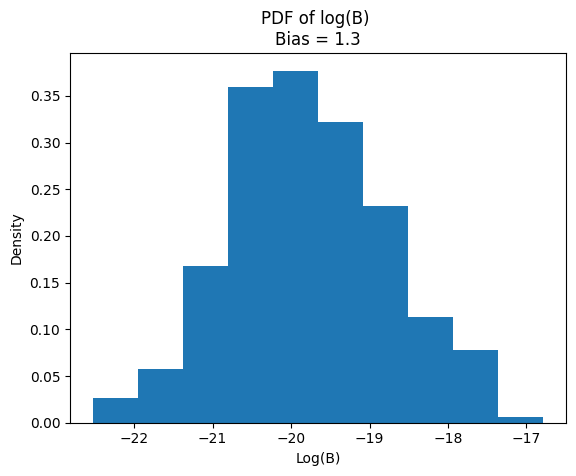

In [8]:
#Example of plotting the pdf of log_grad_b of our cutout centers. This value is what the cutouts were sampled from.

hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=10, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.xlabel("Log(B)")
plt.ylabel("Density")
plt.title("PDF of log(B) \nBias = 1.3")

plt.show()

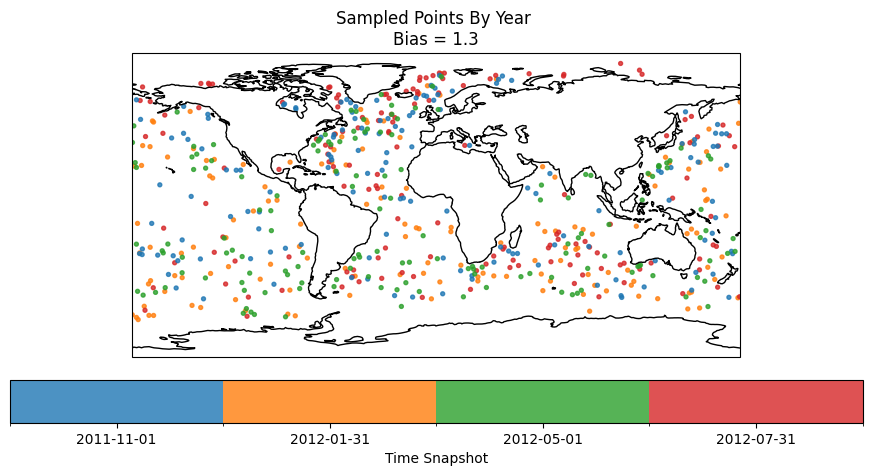

In [32]:
# Lets' see where all of our cutouts were sampled from. Colored by snapshot time.

lats = meta_df["center_lat"].values
lons = meta_df["center_lon"].values

timestamps = pd.to_datetime(meta_df["time_snapshot"])

timestamps = pd.Series(u.strftime("%Y-%m-%d") for u in timestamps)

unique_times = timestamps.sort_values().unique()

time_to_index = {t: i for i, t in enumerate(unique_times)}

time_indices = np.array([time_to_index[t] for t in timestamps])
n_times = len(unique_times)

# discrete colormap
cmap = plt.get_cmap("tab10")#, n_times)
norm = BoundaryNorm(np.arange(-0.5, n_times + 0.5, 1), n_times)


fig = plt.figure(figsize=(11, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

sc = ax.scatter(
    lons,
    lats,
    c=time_indices,
    cmap=cmap,
    norm=norm,
    s=8,
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# discrete colorbar with timestamp labels
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    ticks=np.arange(n_times)
)

cbar.set_ticklabels([str(t) for t in unique_times])
cbar.set_label("Time Snapshot")

plt.title("Sampled Points By Year \nBias = 1.3")
plt.show()

# Now we will load the actual data

In [33]:
# This reader class will allow easy access to the remotely stored data

reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

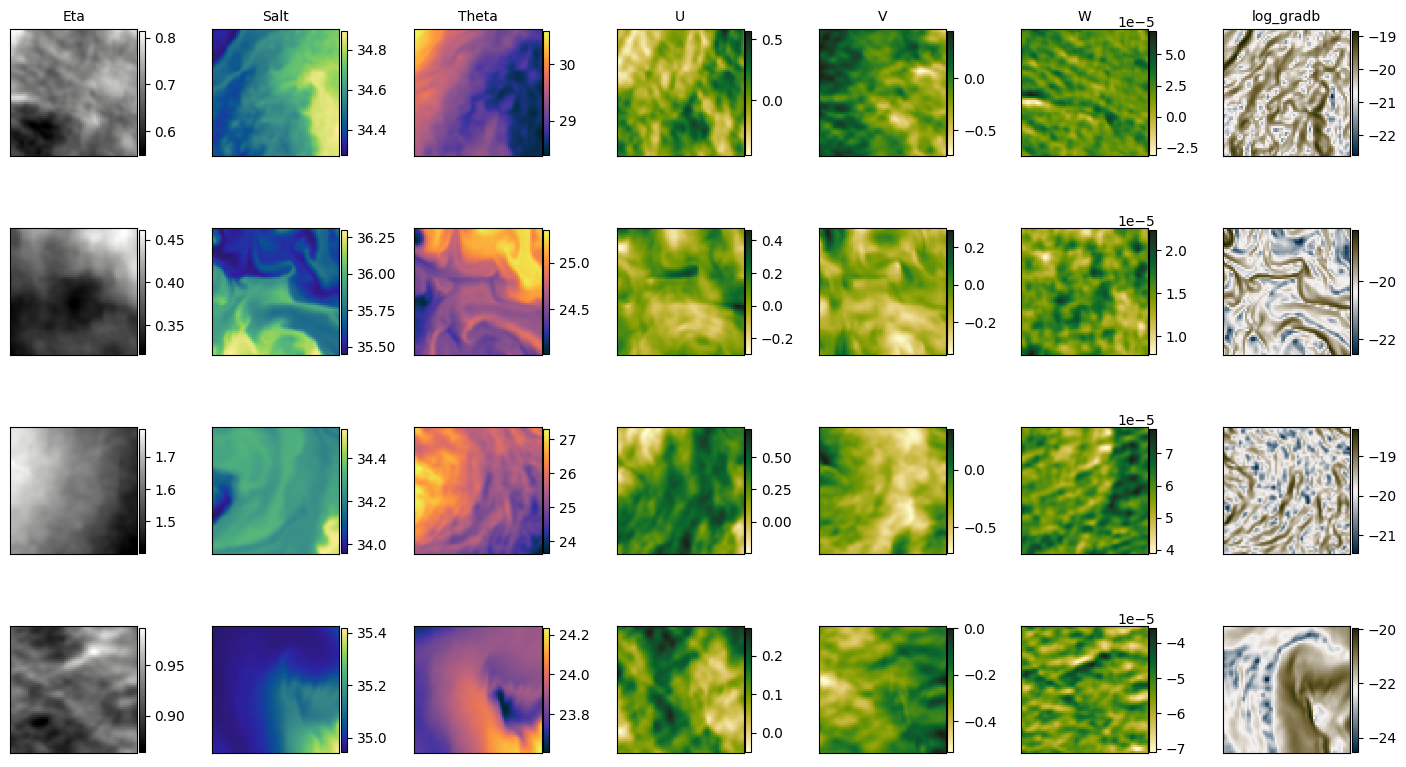

,dataset_index,id,native_grid,center_grid_face,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,b'8af739f848644f3db9aa88355f52476a',94a99bbe-b11d-4b10-bcf1-ce0494f7177a,LLC4320,8,584,1595,-16.615614,154.177078,150,147.055254,146.485937,"[67, 73]",-19.564291,2012-01-31 10:00:00
1,b'dc669f0d90824e8d9d5c70ecf732ad06',6c405bd6-e4c8-4645-b0eb-d1b802b92fed,LLC4320,10,3277,3985,19.872784,-59.718750,150,148.203711,148.122162,"[69, 75]",-19.860787,2012-01-31 10:00:00
2,b'f178d51baeac4a82909170ee15950d93',07f00985-7ae3-401b-a508-4b619c7a65ba,LLC4320,5,528,3826,23.326685,131.718750,150,148.881335,148.586536,"[77, 71]",-19.267859,2012-05-01 16:00:00
3,b'05cf8c1679844075a29d4aca47739cdf',7743bea1-f850-4ae3-9a0e-518a00337327,LLC4320,11,300,1076,-6.867203,-121.739586,150,148.817254,147.173172,"[65, 71]",-20.597722,2011-11-01 04:00:00


In [35]:
# Use the reader to plot out a few random samples from our data

# todo it would be cool to add a lat lon pin to each sample

import cmocean
feature_channels = ["Eta", "Salt", "Theta", "U", "V", "W", "log_gradb"] # todo add to config

def plot_image_features(imgs, ids):
    """
    imgs: (N, C, H, W)
    """

    N, C, H, W = imgs.shape

    fig = plt.figure(figsize=(2.5*(C+1), 2.5*N))
    gs = fig.add_gridspec(N, C + 1, wspace=0.5, hspace=0.15)

    for i in range(N):
        row_data = imgs[i]

        for c in range(C):
            ax = fig.add_subplot(gs[i, c])

            # vmin = np.nanmin(row_data[c])
            # vmax = np.nanmax(row_data[c])


            if c == 0:
                cmap = cmocean.cm.gray
            elif c == 1 :
                cmap = cmocean.cm.haline
            elif c == 2 :
                cmap = cmocean.cm.thermal
            elif c == 6 :
                cmap = cmocean.cm.diff
            else :
                cmap = cmocean.cm.speed



            im = ax.imshow(row_data[c], cmap=cmap) #, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])

            if i == 0:
                ax.set_title(f"{feature_channels[c]}", fontsize=10)

            fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.01 #format="%4.2"
            )

    plt.show()

rand_indices = np.random.randint(0, reader.num_images, size=4)
imgs, ids = reader.get_images(rand_indices)

plot_image_features(imgs, ids)

# Metadata for each sample
subset_df = (
    meta_df
    .set_index("dataset_index")
    .loc[ids]
    .reset_index()
)
subset_df

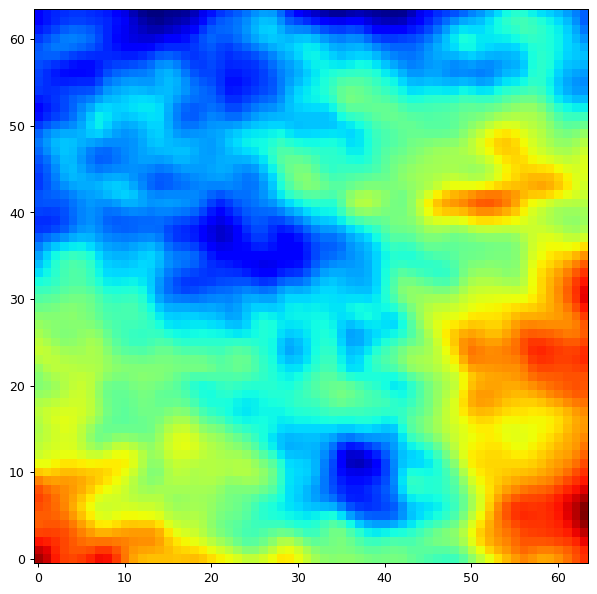

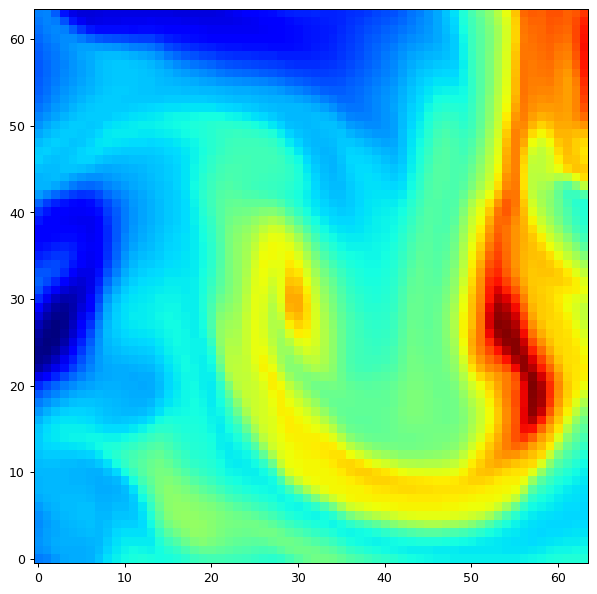

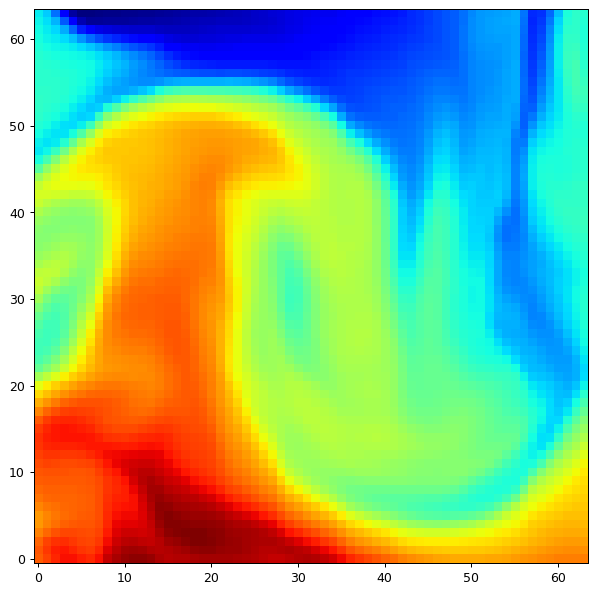

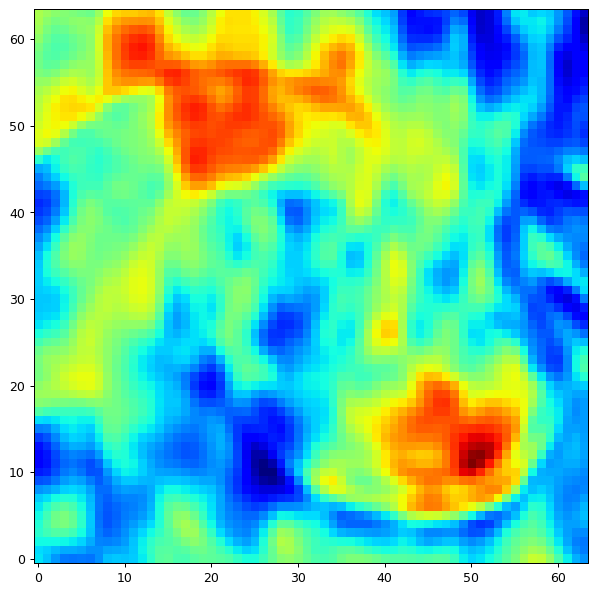

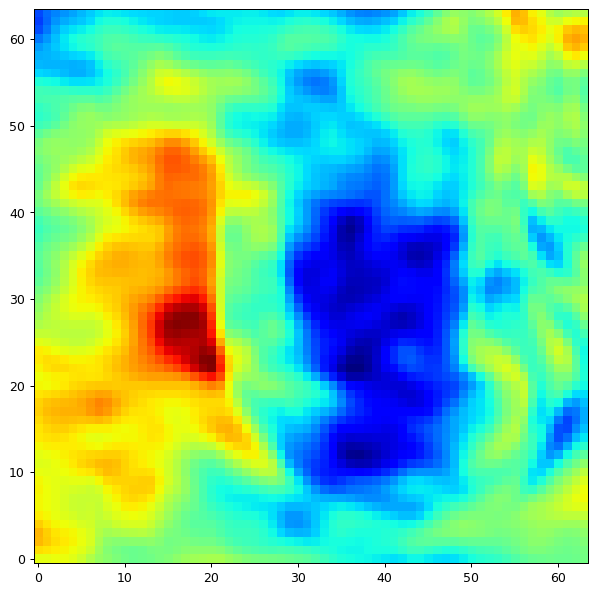

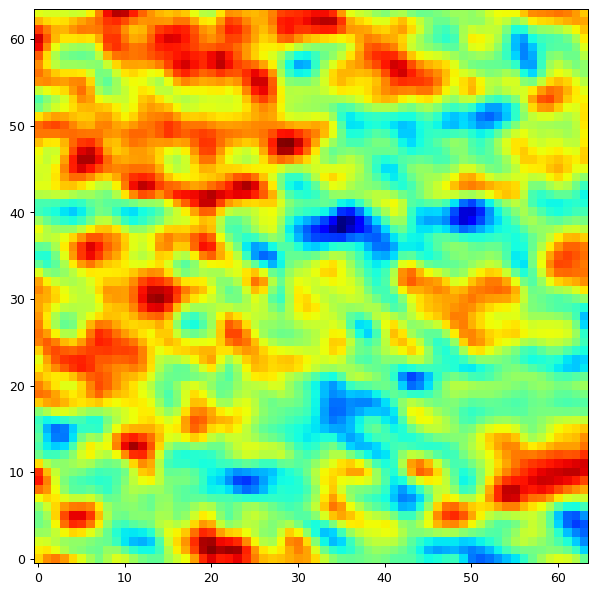

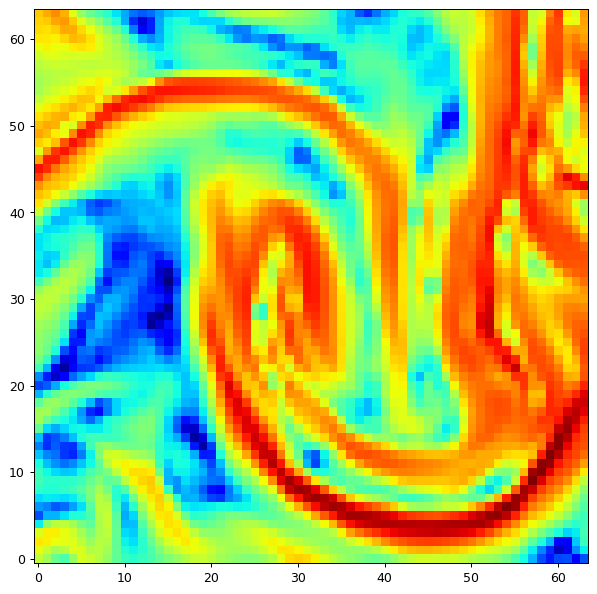

In [11]:
# Plot out every feature of an image from our data

img, img_id = reader.get_image(0)
for i in range(len(img)):

    plt.figure(figsize=(8,8), dpi= 90)
    plt.imshow(img[i],origin='lower',cmap='jet')